<a href="https://colab.research.google.com/github/Asmaul-Urme/Machine-Learning/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#In this project we are going to predict house price . we are using the dateset boston_house_price.
We are also going to use XGBoost Regression algorithm.

In [1]:
#importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics


In [6]:
boston_data = pd.read_csv("/content/Housing 2.csv")

In [8]:
boston_data.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [7]:
boston_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [9]:
#shape
boston_data.shape

(545, 13)

In [10]:
#missing values
boston_data.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [13]:
boston_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [18]:
boston = boston_data.drop(['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus'],axis = 1)

In [20]:
#understanding correlation
correlation = boston.corr()


<Axes: >

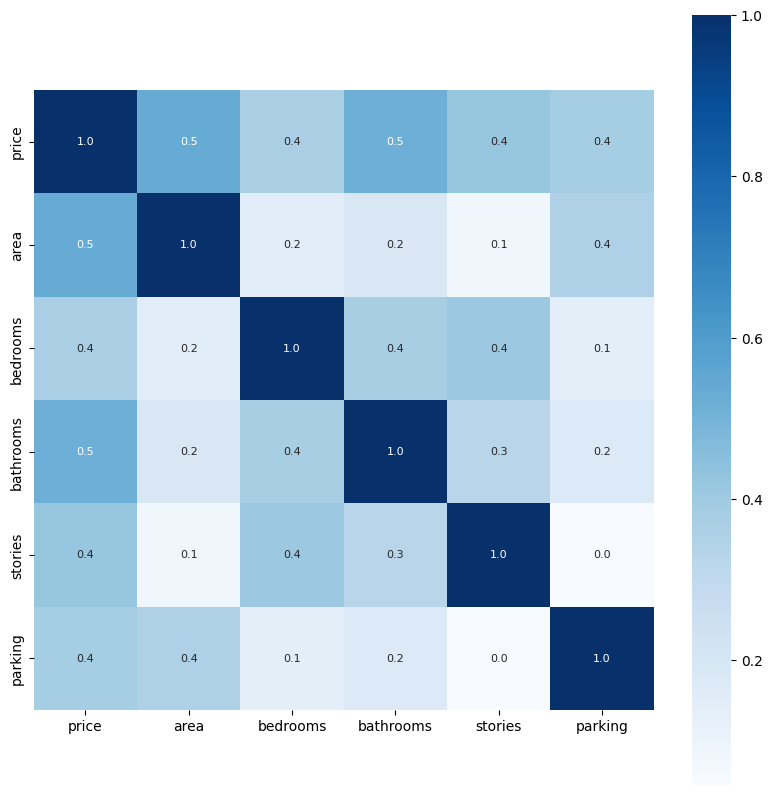

In [22]:
plt.figure(figsize =(10,10))
sns.heatmap(correlation,cbar = True, square = True , fmt = '.1f', annot = True, annot_kws = {'size':8},cmap ='Blues')

In [23]:
#separating the data and label
X = boston.drop(['price'],axis=1)
Y = boston['price']
print(X)
print(Y)

     area  bedrooms  bathrooms  stories  parking
0    7420         4          2        3        2
1    8960         4          4        4        3
2    9960         3          2        2        2
3    7500         4          2        2        3
4    7420         4          1        2        2
..    ...       ...        ...      ...      ...
540  3000         2          1        1        2
541  2400         3          1        1        0
542  3620         2          1        1        0
543  2910         3          1        1        0
544  3850         3          1        2        0

[545 rows x 5 columns]
0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64


In [24]:
#splitting data into training data and test data
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=.2,random_state =2)

In [25]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(545, 5)
(436, 5)
(109, 5)


#Model Training
XGBoost Regressor

In [27]:
#loading the model
model = XGBRegressor()

In [29]:
#training the model with x_train
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

#Evaluation

In [33]:
#Prediction on training data
training_data_prediction = model.predict(X_train)

In [34]:
print(training_data_prediction )

[ 3420302.2  4237653.   2515418.2  4950223.   4099487.2  7345578.
  3087323.2  2766970.5  6928292.5  4597473.   3430693.8  3411721.5
  6122547.   5760622.   7658497.   3961564.8  5080206.5  4542765.
  7619728.5  4044779.2  4040915.5  3218254.8  5299501.   4416962.5
  3929403.   4279347.5  6774748.   9181800.   4621186.   3353261.8
  4061792.5  3177262.2  2595471.2  3917471.2  4395547.   3085494.5
  4860064.   3841533.8  2011461.1  7991436.   4053961.8 12132570.
  8518272.   7293174.5  4140822.8  3126925.2  4089616.2  3475126.
  3382802.5  2470844.2  5548034.5  4060728.5  3911440.   3422239.8
  4230979.   5389872.5  3652815.2  3794333.8  3750801.   4138126.5
  7345578.   4241929.5  6042503.5  3792662.8  3738665.5  5333687.
  6409431.   6012464.   5455705.5  5385725.   3286394.5  3693268.2
  2992060.8  4921562.5  5376638.5  3789208.5  5882819.   4168185.5
  6185529.5  5386382.5  2984277.8  3398643.8  6334564.5  4787313.
  5837654.5  8405725.   2759924.   3116894.   9721711.   4163814.5
 

In [35]:
#R squraed error
score1 = metrics.r2_score(Y_train,training_data_prediction )

In [36]:
print(score1)

0.9789071083068848


In [37]:
#mean absolute error
mean_absolute_error = metrics.mean_absolute_error(Y_train,training_data_prediction )

In [40]:
print("R squred error",score1)
print("mean absolute error",mean_absolute_error)

R squred error 0.9789071083068848
mean absolute error 169212.734375


In [42]:
#testing on test data
test_data = model.predict(X_test)

In [43]:
score2 = metrics.r2_score(Y_test,test_data)
mean_absolute_error1 = metrics.mean_absolute_error(Y_test,test_data)
print("R squred error",score2)
print("mean absolute error",mean_absolute_error1)


R squred error 0.04430198669433594
mean absolute error 1294156.625


#visualizing the actual prices and predicted prices

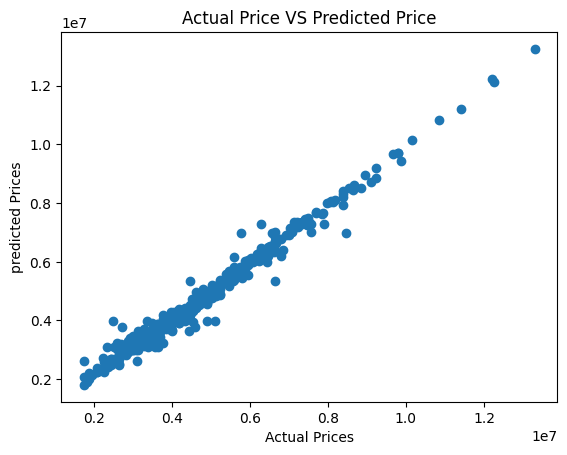

In [45]:
plt.scatter(Y_train,training_data_prediction )
plt.xlabel('Actual Prices')
plt.ylabel('predicted Prices')
plt.title('Actual Price VS Predicted Price')
plt.show()